# Regresión logística en Python
## Caso: Abandono Financiero

**Curso:** Machine Learning en Economía y Finanzas · FCEA · Clase 8 · 2026-2

**Presentado por Santiago Loaiza y Leonardo Rojas**
Base de datos: `C:\Users\xhann\Downloads\Talle_ML_Reg_Log\Taller_Regresion_Logistica\abandono_producto_financiero.csv`

Una entidad de banca de personas ha registrado, en un corte reciente, un aumento de clientes que cierran
la relación (cuenta o producto). El área de retención necesita pasar de la tasa agregada de la cartera a una
probabilidad individual: qué cliente, con qué perfil, tiene mayor 𝑃 (abandono = 1 ∣ 𝑥).
Ese cálculo no sustituye la decisión comercial. Sirve para ordenar la cartera: a quién contactar primero, con
qué umbral se declara «en riesgo» y qué error se acepta (llamar a quien se iba a quedar frente a no ver a
quien sí se va).

Cada fila de `abandono_producto_financiero.csv` es un cliente de banca de personas observado una vez (corte transversal). El desenlace `abandono` vale 1 si el cliente cerró la relación con el banco y 0 si permanece. El objetivo es estimar

$$
P(\text{abandono}=1 \mid x) = \Lambda(x\beta) = \frac{e^{x\beta}}{1+e^{x\beta}}
$$

con `smf.logit`, usando `smf.ols` solo como contraste, y cerrar con la matriz de confusión en test, igual que en la Clase 8.


In [2]:
#Se importan las librerías que vamos a utilizar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CSV = "abandono_producto_financiero.csv"

# 1. Estructura de los datos

In [3]:
banco_crudo = pd.read_csv(CSV, encoding="utf-8")
banco_crudo.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.0000,1,1,1,"101,348.8800",1
1,2,15647311,Hill,608,España,Mujer,41,1,"83,807.8600",1,0,1,"112,542.5800",0
2,3,15619304,Onio,502,Francia,Mujer,42,8,"159,660.8000",3,1,0,"113,931.5700",1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.0000,2,0,0,"93,826.6300",0
4,5,15737888,Mitchell,850,España,Mujer,43,2,"125,510.8200",1,1,1,"79,084.1000",0


In [4]:
banco_crudo.columns.tolist()

['numero_fila',
 'id_cliente',
 'apellido',
 'puntaje_crediticio',
 'pais',
 'sexo',
 'edad',
 'antiguedad',
 'saldo',
 'numero_productos',
 'tiene_tarjeta',
 'miembro_activo',
 'salario_estimado',
 'abandono']

In [5]:
banco_crudo.dtypes

numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

In [6]:
banco_crudo.describe(include='all')

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,"10,000.0000","10,000.0000",10000,"10,000.0000",10000,10000,"10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000"
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,Francia,Hombre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"5,000.5000","15,690,940.5694",NaN,650.5288,NaN,NaN,38.9218,5.0128,"76,485.8893",1.5302,0.7055,0.5151,"100,090.2399",0.2037
std,"2,886.8957","71,936.1861",NaN,96.6533,NaN,NaN,10.4878,2.8922,"62,397.4052",0.5817,0.4558,0.4998,"57,510.4928",0.4028
min,1.0000,"15,565,701.0000",NaN,350.0000,NaN,NaN,18.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.5800,0.0000
25%,"2,500.7500","15,628,528.2500",NaN,584.0000,NaN,NaN,32.0000,3.0000,0.0000,1.0000,0.0000,0.0000,"51,002.1100",0.0000
50%,"5,000.5000","15,690,738.0000",NaN,652.0000,NaN,NaN,37.0000,5.0000,"97,198.5400",1.0000,1.0000,1.0000,"100,193.9150",0.0000
75%,"7,500.2500","15,753,233.7500",NaN,718.0000,NaN,NaN,44.0000,7.0000,"127,644.2400",2.0000,1.0000,1.0000,"149,388.2475",0.0000


In [7]:
banco_crudo.isna().sum()

numero_fila           0
id_cliente            0
apellido              0
puntaje_crediticio    0
pais                  0
sexo                  0
edad                  0
antiguedad            0
saldo                 0
numero_productos      0
tiene_tarjeta         0
miembro_activo        0
salario_estimado      0
abandono              0
dtype: int64

## Descripción de la base de datos

La base de datos contiene información de 10.000 clientes de una entidad financiera y 14 variables relacionadas con sus características personales, financieras y comportamiento como clientes.

Para el análisis se excluyen las variables `numero_fila`, `id_cliente` y `apellido`, por ser identificadores o datos personales. La variable objetivo es `abandono`, que toma el valor de 1 si el cliente abandona la entidad y 0 si permanece.

La información incluye variables como edad, puntaje crediticio, saldo, antigüedad, número de productos y actividad del cliente. El 20,37% de los registros corresponde a clientes que abandonaron la entidad y el 79,63% a clientes que permanecen.


De acuerdo con las instrucciones que tenemos en la guía `Factores con niveles fijos: pais = Francia, Alemania, España; sexo = Mujer, Hombre`, procedemos a limpiar un poco los datos, por lo que se eliminan los identificadores (`numero_fila`, `id_cliente`, `apellido`), que no son realmente necesarios para el análisis. `pais` y `sexo` pasan a `category` con los niveles del diccionario, en ese orden, para que la **referencia** de `C(pais)` sea Francia y la de `C(sexo)` sea Mujer. `abandono` queda como entero 0/1.

In [8]:
banco = banco_crudo.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

banco["pais"] = pd.Categorical(banco["pais"], categories=["Francia", "Alemania", "España"])
banco["sexo"] = pd.Categorical(banco["sexo"], categories=["Mujer", "Hombre"])
banco["abandono"] = banco["abandono"].astype(int)

print(banco.shape)
banco.dtypes

(10000, 11)


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

In [9]:
# Verificamos
print(banco["pais"].isna().sum(), banco["sexo"].isna().sum())
print(banco["pais"].cat.categories.tolist(), banco["sexo"].cat.categories.tolist())

0 0
['Francia', 'Alemania', 'España'] ['Mujer', 'Hombre']


In [10]:
cuantitativas = ["puntaje_crediticio", "edad", "antiguedad", "saldo",
                 "numero_productos", "salario_estimado"]
categoricas_binarias = ["pais", "sexo", "tiene_tarjeta", "miembro_activo", "abandono"]

print("Variables base cruda:", banco_crudo.shape[1])
print("Variables tras quitar identificadores:", banco.shape[1],
      "(", banco.shape[1] - 1, "explicativas + la respuesta )")
print("Cuantitativas:", len(cuantitativas), cuantitativas)
print("Categóricas o binarias:", len(categoricas_binarias), categoricas_binarias)

Variables base cruda: 14
Variables tras quitar identificadores: 11 ( 10 explicativas + la respuesta )
Cuantitativas: 6 ['puntaje_crediticio', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
Categóricas o binarias: 5 ['pais', 'sexo', 'tiene_tarjeta', 'miembro_activo', 'abandono']



**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**
La base cruda tiene **14 variables** y 10.000 filas (clientes), sin valores faltantes. Al eliminar los tres identificadores quedan **11 variables**: 10 explicativas ($x$) y la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**
**6**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` (entero, un conteo) y `salario_estimado`.

**3. ¿Cuántas son categóricas o binarias (incluyendo `abandono`)?**
**5**: dos categóricas de texto (`pais` con 3 niveles, `sexo` con 2) y tres binarias 0/1 (`tiene_tarjeta`, `miembro_activo` y la respuesta `abandono`).

**4. ¿Qué implica esta mezcla para el logit en Python?**
Las numéricas y las binarias 0/1 entran directamente a la fórmula: una binaria ya es una dummy, así que su coeficiente compara el grupo 1 contra el grupo 0. Las de texto necesitan dummies. Con `C(pais)` y `C(sexo)`, patsy crea automáticamente $k-1$ dummies por factor (dos para país, una para sexo) y deja fuera el **primer nivel** de la categoría como referencia (Francia y Mujer), lo que evita la trampa de las variables ficticias (colinealidad perfecta con el intercepto). Hacer las dummies a mano (`pd.get_dummies`) es equivalente, pero obliga a borrar una columna por factor, a elegir la referencia uno mismo y a reproducir exactamente las mismas columnas al predecir sobre test o sobre perfiles nuevos. Con `C(·)` y categorías fijas, `predict` hace esa codificación sola y de forma consistente.

# 2. Descriptivo univariado

In [11]:
banco['abandono'].value_counts()

abandono
0    7963
1    2037
Name: count, dtype: int64

In [12]:
banco['abandono'].value_counts(normalize=True)

abandono
0   0.7963
1   0.2037
Name: proportion, dtype: float64

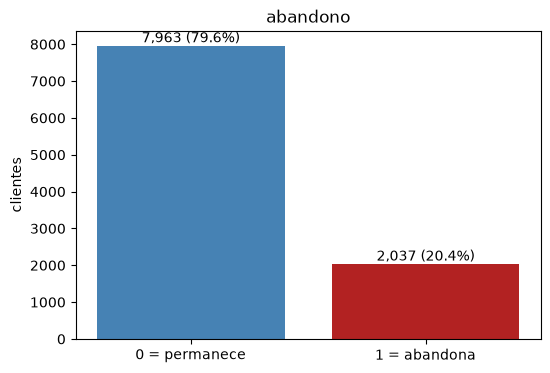

In [13]:
conteo = banco["abandono"].value_counts().sort_index()
plt.bar(["0 = permanece", "1 = abandona"], conteo.values, color=["steelblue", "firebrick"])
for i, v in enumerate(conteo.values):
    plt.text(i, v, f"{v:,} ({v / conteo.sum():.1%})", ha="center", va="bottom")
plt.ylabel("clientes")
plt.title("abandono")
plt.show()

La gráfica muestra que el 79,63% de los clientes permanece en la entidad, mientras que el 20,37% abandona, evidenciando un desbalance en la variable objetivo.

La tabla descriptiva muestra que la edad promedio es de 38,92 años, con una mediana de 37 años. El puntaje crediticio promedio es de 650,53 y el saldo promedio es de 76.485,89, aunque su mediana es superior (97.198,54), lo que indica una distribución con concentración de clientes con saldo cero o bajo y valores elevados en otros clientes. Finalmente, el salario estimado presenta una media cercana a 100.090 y una mediana similar, reflejando una distribución relativamente centrada alrededor de ese valor.

In [14]:
banco[['edad', 'puntaje_crediticio', 'saldo', 'salario_estimado']].describe()

,edad,puntaje_crediticio,saldo,salario_estimado
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,38.9218,650.5288,"76,485.8893","100,090.2399"
std,10.4878,96.6533,"62,397.4052","57,510.4928"
min,18.0000,350.0000,0.0000,11.5800
25%,32.0000,584.0000,0.0000,"51,002.1100"
50%,37.0000,652.0000,"97,198.5400","100,193.9150"
75%,44.0000,718.0000,"127,644.2400","149,388.2475"
max,92.0000,850.0000,"250,898.0900","199,992.4800"


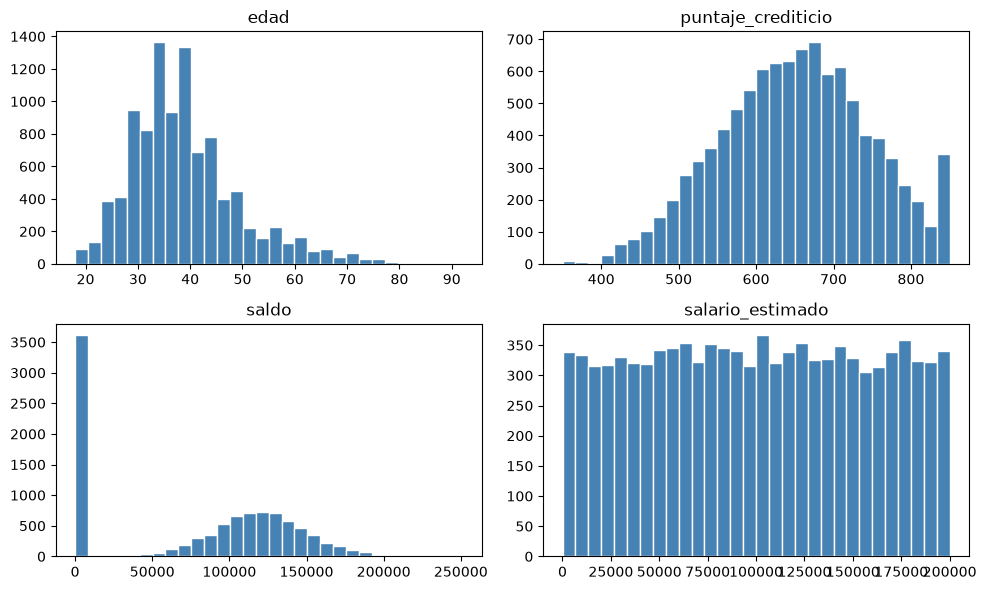

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.ravel(), ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]):
    ax.hist(banco[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()


*Edad*
- La distribución es unimodal y con *cola larga a la derecha*. La mayoría de los clientes está entre los 30 y los 45 años, con el pico hacia los 35 a 40.
- La mediana es 37 y la media 38.9. La media queda algo por encima porque unos pocos clientes llegan hasta los 92 años.
- La cartera es de adultos jóvenes y de mediana edad. Los clientes mayores de 60 son pocos, lo que ayuda a entender por qué la edad tiene valores atípicos altos en los boxplots.

*Puntaje crediticio*
- Tiene forma de campana, centrada cerca de 650 (media 650.5, mediana 652), con una *cola izquierda un poco más larga*: hay clientes con puntajes bajos, hasta 350.
- Al final, cerca del máximo de 850, la barra vuelve a subir. Esto sugiere que el puntaje está *topado en 850* y que ahí se acumulan los clientes que superan ese límite.
- Corrijo lo que escribí en la sección 2 del cuaderno, donde lo llamé «casi simétrico»: es aproximadamente simétrico, pero con esa cola izquierda y el repunte en 850.

*Saldo*
- Es la gráfica más distinta: una *barra enorme en 0* (cerca de 3 600 clientes, el 36.17 %) y, aparte, una campana centrada hacia los 120 000 (la mediana entre quienes tienen saldo positivo es 119 791).
- No es una variable continua «normal». Son dos grupos mezclados: clientes con cuenta vacía y clientes con saldo.
- Esto explica por qué en el bivariado la mediana del saldo engaña. Tienen saldo 0 el 39.1 % de quienes permanecen y el 24.5 % de quienes abandonan.

*Salario estimado*
- Es prácticamente *uniforme entre 0 y 200 000*, con barras de altura casi igual (media 100 090).
- Una variable uniforme y sin estructura no discrimina entre clientes. Eso es coherente con que no resulte significativa en el modelo completo (p = 0.086 en fit6) y con que se haya descartado en fit5.

In [ ]:
(banco['saldo'] == 0).mean()  # proporción de clientes con saldo exactamente 0


miembro_activo
0    4849
1    5151
Name: count, dtype: int64

In [18]:
banco['pais'].value_counts()


pais
Francia     5014
Alemania    2509
España      2477
Name: count, dtype: int64

In [19]:
banco['sexo'].value_counts()


sexo
Hombre    5457
Mujer     4543
Name: count, dtype: int64

In [20]:
banco['numero_productos'].value_counts().sort_index()


numero_productos
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [21]:
banco['miembro_activo'].value_counts().sort_index()

miembro_activo
0    4849
1    5151
Name: count, dtype: int64

In [22]:
# Accuracy del clasificador trivial que siempre dice «permanece»
pred_trivial = np.zeros(len(banco), dtype=int)
print("Accuracy trivial:", (pred_trivial == banco["abandono"]).mean())
print("Abandonos detectados por el trivial:", ((pred_trivial == 1) & (banco["abandono"] == 1)).sum())

Accuracy trivial: 0.7963
Abandonos detectados por el trivial: 0


**Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya parece bueno si uno solo mira la accuracy?**
Abandonaron **2.037 de 10.000 clientes, el 20,37 %**; permanecen 7.963 (79,63 %). La clase 1 es la minoritaria, aproximadamente uno de cada cinco.

Un clasificador que responda siempre «permanece» acierta en todos los que se quedan, así que su exactitud es **79,6 %** sin usar ninguna variable. Pero detecta **cero** abandonos: su sensibilidad es 0 y no le sirve al área de retención, que justamente quiere encontrar a los que se van. Por eso la accuracy no basta como criterio: cualquier modelo tiene que compararse contra ese 79,6 % base y, sobre todo, mirarse por sensibilidad y especificidad 

# 3. Bivariado con la respuesta

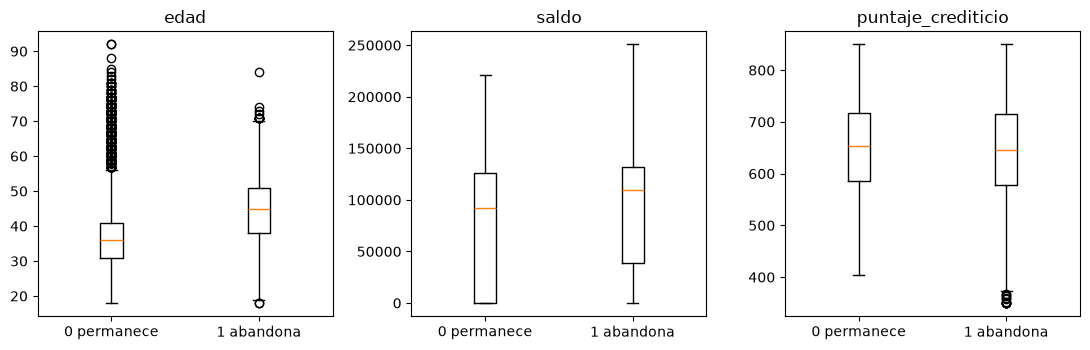

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, col in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [banco.loc[banco["abandono"] == k, col] for k in [0, 1]]
    ax.boxplot(grupos)
    ax.set_xticks([1, 2], ["0 permanece", "1 abandona"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [27]:
banco.groupby('abandono')[['edad', 'saldo', 'puntaje_crediticio']].mean()

,edad,saldo,puntaje_crediticio
abandono,,,
0,37.4084,"72,745.2968",651.8532
1,44.8380,"91,108.5393",645.3515


In [24]:
banco.groupby('abandono')[['edad', 'saldo', 'puntaje_crediticio']].median()

,edad,saldo,puntaje_crediticio
abandono,,,
0,36.0000,"92,072.6800",653.0000
1,45.0000,"109,349.2900",646.0000


In [26]:
banco.groupby('abandono')[['edad', 'saldo', 'puntaje_crediticio']].quantile([0.25, 0.75])

edad        saldo  puntaje_crediticio
abandono                                                
0        0.2500 31.0000       0.0000            585.0000
         0.7500 41.0000 126,410.2800            718.0000
1        0.2500 38.0000  38,340.0200            578.0000
         0.7500 51.0000 131,433.3300            716.0000

In [28]:
banco.groupby('abandono')['saldo'].apply(lambda s: (s == 0).mean())  # proporción con saldo 0 en cada grupo

abandono
0   0.3914
1   0.2455
Name: saldo, dtype: float64

Tablas cruzadas (conteo y tasa de abandono por fila) y prueba ji-cuadrado. Se agrega la **V de Cramér**, $V=\sqrt{\chi^2 / (n\,(\min(r,c)-1))}$, que escala el ji-cuadrado entre 0 y 1 y permite comparar la fuerza de la asociación entre tablas de distinto tamaño.

In [29]:
def tabla_chi2(var, datos=banco):
    tab = pd.crosstab(datos[var], datos["abandono"])
    chi2, p, dof, _ = chi2_contingency(tab)
    n = tab.values.sum()
    v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    print(f"=== {var} ===")
    print(tab)
    print("\nTasa de abandono por fila:")
    print(pd.crosstab(datos[var], datos["abandono"], normalize="index").round(3))
    print(f"\nchi2 = {chi2:.1f}  gl = {dof}  p = {p:.3g}  V de Cramér = {v:.3f}\n")
    return {"variable": var, "chi2": chi2, "gl": dof, "p": p, "V_Cramer": v}

resumen = [tabla_chi2(v) for v in ["miembro_activo", "numero_productos", "pais"]]

=== miembro_activo ===
abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735

Tasa de abandono por fila:
abandono            0      1
miembro_activo              
0              0.7310 0.2690
1              0.8570 0.1430

chi2 = 243.0  gl = 1  p = 8.79e-55  V de Cramér = 0.156

=== numero_productos ===
abandono             0     1
numero_productos            
1                 3675  1409
2                 4242   348
3                   46   220
4                    0    60

Tasa de abandono por fila:
abandono              0      1
numero_productos              
1                0.7230 0.2770
2                0.9240 0.0760
3                0.1730 0.8270
4                0.0000 1.0000

chi2 = 1503.6  gl = 3  p = 0  V de Cramér = 0.388

=== pais ===
abandono     0    1
pais               
Francia   4204  810
Alemania  1695  814
España    2064  413

Tasa de abandono por fila:
abandono      0      1
pais                  
Francia  0.8380

In [30]:
# Para comparar con las continuas, la edad en quintiles con la misma prueba
banco_q = banco.assign(edad_quintil=pd.qcut(banco["edad"], 5))
resumen.append(tabla_chi2("edad_quintil", banco_q))

=== edad_quintil ===
abandono           0    1
edad_quintil             
(17.999, 31.0]  2191  181
(31.0, 35.0]    1615  166
(35.0, 40.0]    1927  339
(40.0, 46.0]    1211  485
(46.0, 92.0]    1019  866

Tasa de abandono por fila:
abandono            0      1
edad_quintil                
(17.999, 31.0] 0.9240 0.0760
(31.0, 35.0]   0.9070 0.0930
(35.0, 40.0]   0.8500 0.1500
(40.0, 46.0]   0.7140 0.2860
(46.0, 92.0]   0.5410 0.4590

chi2 = 1242.9  gl = 4  p = 7.86e-268  V de Cramér = 0.353



In [31]:
resumen += [tabla_chi2(v) for v in ["sexo", "tiene_tarjeta"]]
pd.DataFrame(resumen).sort_values("V_Cramer", ascending=False)

=== sexo ===
abandono     0     1
sexo                
Mujer     3404  1139
Hombre    4559   898

Tasa de abandono por fila:
abandono      0      1
sexo                  
Mujer    0.7490 0.2510
Hombre   0.8350 0.1650

chi2 = 112.9  gl = 1  p = 2.25e-26  V de Cramér = 0.106

=== tiene_tarjeta ===
abandono          0     1
tiene_tarjeta            
0              2332   613
1              5631  1424

Tasa de abandono por fila:
abandono           0      1
tiene_tarjeta              
0             0.7920 0.2080
1             0.7980 0.2020

chi2 = 0.5  gl = 1  p = 0.492  V de Cramér = 0.007



,variable,chi2,gl,p,V_Cramer
1,numero_productos,"1,503.6294",3,0.0000,0.3878
3,edad_quintil,"1,242.9285",4,0.0000,0.3526
2,pais,301.2553,2,0.0000,0.1736
0,miembro_activo,242.9853,1,0.0000,0.1559
4,sexo,112.9186,1,0.0000,0.1063
5,tiene_tarjeta,0.4713,1,0.4924,0.0069


## Preguntas Sección 3
**6. Distribución de la edad entre quien abandona y quien permanece.**
Quien abandona es claramente mayor. La mediana de edad es **45 años** entre los que se van y **36** entre los que se quedan (medias 44,8 frente a 37,4). En el boxplot, toda la caja del grupo 1 está desplazada hacia arriba: su rango intercuartílico va de 38 a 51 años, mientras que el del grupo 0 va de 31 a 41, así que el cuartil inferior de los que abandonan ya supera la mediana de los que permanecen. En el grupo 0 aparecen muchos atípicos de edad alta, lo que indica que los clientes mayores que se quedan son la excepción. La tabla por quintiles lo confirma: la tasa de abandono sube de 7,6 % (18–31 años) a 45,9 % (47 años o más).

**7. `saldo` y `puntaje_crediticio` entre los dos grupos.**
*Saldo:* quienes abandonan tienen más saldo. La mediana es 109.349 frente a 92.073, y la media 91.109 frente a 72.745. Buena parte de la diferencia viene de la masa en cero: el 39 % de los que permanecen tiene saldo 0, contra el 25 % de los que se van, lo que hunde la caja del grupo 0 hasta cero. Es una diferencia real pero moderada, y las cajas se solapan mucho.
*Puntaje crediticio:* prácticamente no hay diferencia. Medianas de 646 (abandona) y 653 (permanece), con cajas casi idénticas (≈ 580–718). El puntaje no separa a los grupos a simple vista.

**8. `miembro_activo` y abandono.**
Sí: los activos abandonan bastante menos. La tasa de abandono es **14,3 %** entre activos y **26,9 %** entre inactivos, casi el doble. El ji-cuadrado es 243,0 con 1 gl y $p \approx 10^{-55}$, así que la independencia se rechaza con claridad (V de Cramér = 0,16).

**9. `numero_productos` y abandono. ¿Más productos se asocia siempre con menos abandono?**
No. La relación **no es monótona**. Con 1 producto abandona el 27,7 %; con 2, solo el 7,6 % (el mínimo); pero con 3 abandona el **82,7 %** y con 4 el **100 %** (60 de 60). Pasar de 1 a 2 productos protege, pero 3 o más está asociado a un abandono masivo, aunque sean grupos pequeños (266 y 60 clientes). El ji-cuadrado es el más alto de todos: 1.503,6 con 3 gl, $p \approx 0$. Esto importa para el logit: si `numero_productos` entra como variable continua (una sola pendiente), el modelo impone una relación lineal en log-odds que no captura esta forma en U.

**10. ¿Qué variable parece tener mayor relación con el abandono?**
Por las pruebas, **`numero_productos`**: tiene el mayor ji-cuadrado (1.503,6) y la mayor V de Cramér (0,39) entre las categóricas; le siguen `pais` (V = 0,17; Alemania abandona al 32,4 % frente a ≈ 16 % en Francia y España), `miembro_activo` (0,16) y `sexo` (0,11), mientras que `tiene_tarjeta` no tiene relación ($p = 0,49$). Entre las continuas, la más fuerte es **`edad`**: es la única en la que las cajas del boxplot casi no se solapan, y agrupada en quintiles da un ji-cuadrado de 1.242,9 y una V de 0,35, casi al nivel de `numero_productos`. Así, en el bivariado `numero_productos` es la variable con mayor asociación y `edad` es la continua más relevante (y, como se verá en la sección 5, la de mayor $z$ en el logit).